In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from mkid_simulator import MKIDSimulator, ReadoutParams, NoiseParams


In [130]:
#m = MKIDSimulator() # with no arguments, will default to my set parameters.

m = MKIDSimulator(
    fr=5.0e9,          # Resonance frequency (Hz)
    Qi=200000,         # Internal quality factor
    Qc=50000,          # Coupling quality factor
    phi_c=0.1,         # Asymmetry angle (rad)
    tau=50e-9,         # Cable delay (s)
    a=1,             # Complex amplitude (linear)
    noise_params=NoiseParams(
        tls_Sf0=1e8,          # TLS frequency noise at 1 Hz (Hz^2/Hz)
        tls_alpha=0.7,        # TLS spectral slope
        hemt_sigma=0.003,     # HEMT white noise level
        lo_Sphi0=5e-2,        # LO phase noise at 1 Hz (rad^2/Hz)
        lo_alpha=1.0,         # LO phase noise slope
        lo_white=1e-7,        # LO white noise floor
    ),
    readout_params=ReadoutParams(
        f_tone=None,           # None = place on resonance
        f_clean=[              # Two off-resonance cleaning tones
            5.0e9 - 2.0e6,    # 2 MHz below resonance
            5.0e9 + 2.5e6,    # 2.5 MHz above resonance
        ],
        fs=200e3,              # 200 kHz sample rate
    ),
    seed=42,
)

## Part 1: what's an MKID:
MKIDs are superconducting microwave resonators forming an LC circuit. When an above-gap energy quanta (photon, phonon) is absorbed, it can break Cooper pairs into quasiparticles, changing the kinetic inductance and surface resistance of the film. This shifts the resonance frequency $f_r$ and changes the internal quality factor $Q_i$. To read out the detector, we monitor the complex transmission $S_{21}$ of a microwave tone placed near resonance. MKIDS can be useful as both photon detectors, and as environmental sensors for quantum circuits.  

One of the first characterizations we do when we cool down an MKID is to measure S21 resonse as we sweep the frequency of a readout tone. 

In [141]:
f_sweep, S21_sweep =  m.frequency_sweep(4.995e9, 5.0025e9, n_points=500, ifbw=10000, readout_power_dBm=-115)

In [142]:
always_true = True

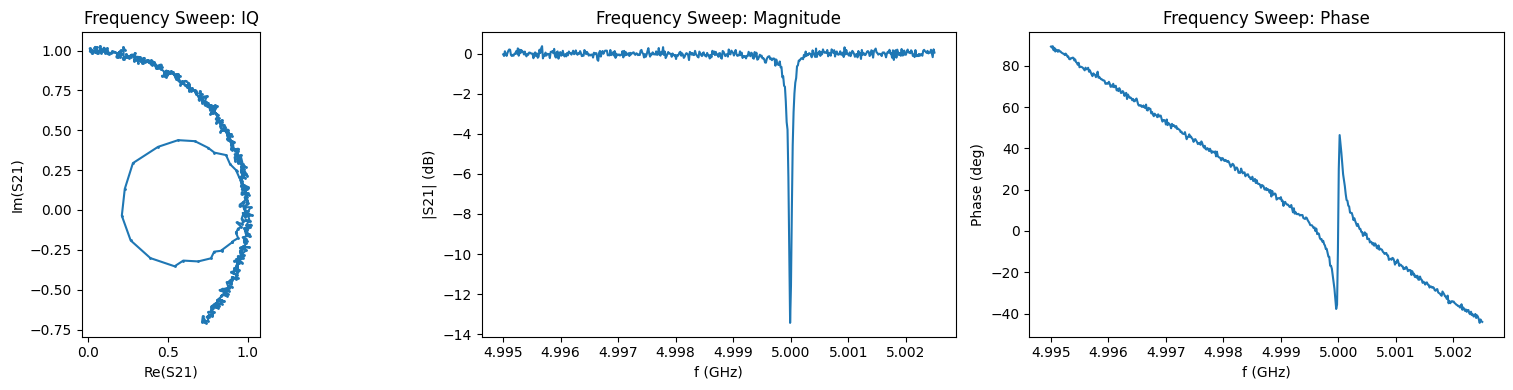

In [143]:
# now plot the results of the frequency sweep:
if always_true:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(S21_sweep.real, S21_sweep.imag, '.-', markersize=2)
    axes[0].set_xlabel('Re(S21)')
    axes[0].set_ylabel('Im(S21)')
    axes[0].set_title('Frequency Sweep: IQ')
    axes[0].set_aspect('equal')

    axes[1].plot(f_sweep/1e9 , 20 * np.log10(np.abs(S21_sweep)))
    axes[1].set_xlabel('f (GHz)')
    axes[1].set_ylabel('|S21| (dB)')
    axes[1].set_title('Frequency Sweep: Magnitude')

    axes[2].plot(f_sweep/1e9 , np.angle(S21_sweep, deg=True))
    axes[2].set_xlabel('f (GHz)')
    axes[2].set_ylabel('Phase (deg)')
    axes[2].set_title('Frequency Sweep: Phase')

    plt.tight_layout()
    plt.savefig('mkid_sweep_demo.png', dpi=150, bbox_inches='tight')
    plt.show()

We can describe our detector's frequency-dependent S21 response to a lorentzian reponse model:

$S_{21}(f)=a e^{-2\pi i \tau (f-f_r)}\left(1-\frac{Q_r}{\hat{Q}_c}\frac{1}{1 + 2iQ_r\frac{f-f_r}{f_r}}\right)$.

Here the quantity inside the parentheses corresponds to the ideal resonator response. Outside, $\tau$, $a$ tell you about the phase delay and off-resonant transmisson through the cryostat respectively. 

$\hat{Q}_\text{c}$ tells you about XXX. 


<span style="color:red">Please fit the frequency depentent S21 resonse to the above equation, to extract:</span> 
$\red{a, \tau, f_r, Q_r, \hat{Q}_c}$.

In [144]:
# write your fitting code here.

## Part 2: Look at events in MKIDs
Now that we know our resonant frequency, We can "stream" the MKID's time-dependent S21 transmission at fixed readout frequencies.

 To start, we will set 3 tones: one on-resonance, and two far off resonance to monitor the other RF electronics in the readout chain. We will call these off-resonance tones our "cleaning" tones. 

In [145]:
#data = m.timestream(d=1, fs=200, f=[1,2,3]) #based on default parameters. 
data = m.generate_timestream_fast(
    duration=1.0,                    # 1 second
    photon_rate=1.0,               # 50 photons/sec
    energy_distribution='uniform',  # Exponential energy distribution
    mean_energy=.32,                 # Mean photon energy (eV)
)

We can plot what this timestream data will look like in complex space, as well as the PSD of the timestreams.  We define a helper PSD funciton first, then plot. 

In [146]:
def PSD(x, fs):
    """Compute the Power Spectral Density (PSD) of a signal x with sampling frequency fs."""
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    psd = (1/(fs*n)) * np.abs(np.fft.rfft(x))**2
    return freqs, psd

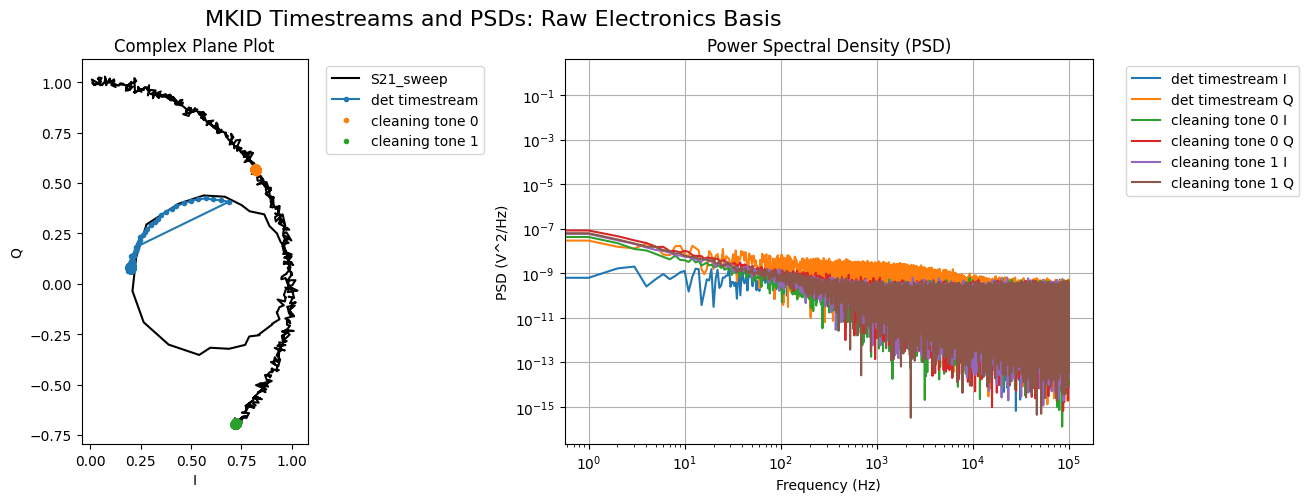

In [147]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

#axs[0]: complex plane plot
axs[0].plot(S21_sweep.real, S21_sweep.imag, 'k-', label='S21_sweep')
axs[0].plot(data.I_det,data.Q_det,'.-', label='det timestream')
for i in range(len(data.I_clean)):
    axs[0].plot(data.I_clean[i], data.Q_clean[i],'.', label=f'cleaning tone {i}')
axs[0].set_xlabel('I')
axs[0].set_ylabel('Q')
axs[0].set_title('Complex Plane Plot')
axs[0].set_aspect('equal')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

#axs[1]: PSDs 
axs[1].set_title('Power Spectral Density (PSD)')
freqs, psd_I = PSD(data.I_det, fs=m.readout.fs)
freqs, psd_Q = PSD(data.Q_det, fs=m.readout.fs)
axs[1].loglog(freqs, psd_I, label='det timestream I')
axs[1].loglog(freqs, psd_Q, label='det timestream Q')

for i in range(len(data.I_clean)):
    freqs_clean, psd_clean_I = PSD(data.I_clean[i], fs=m.readout.fs)
    freqs_clean, psd_clean_Q = PSD(data.Q_clean[i], fs=m.readout.fs)
    axs[1].loglog(freqs_clean, psd_clean_I, label=f'cleaning tone {i} I') 
    axs[1].loglog(freqs_clean, psd_clean_Q, label=f'cleaning tone {i} Q')

axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('PSD (V^2/Hz)')
axs[1].grid()

plt.suptitle('MKID Timestreams and PSDs: Raw Electronics Basis', fontsize=16)
plt.show()

Raw I and Q are defined by the LO phase, which is an an arbitrary reference point. The signal from a frequency shift doesn't necessarily align with either axis. We can rotate to a basis where one quadrature contains (most of) the signal and the other contains (mostly) noise. 

 <span style="color:red"> Experiment with rotating the measured timestream data, in order to generate the highest signal to noise. What are different basis-es you can use to track MKID response? <span>

<span style="color:red">Plot the following (IQ and PSDs): <span>

<span style="color:red">1. timestreams in radius/arc length basis<span>

<span style="color:red">2. timestreams in ideal-resonator basis<span>


In [29]:
## you can plot IQ timestreams and PSDs here.

How does the CSD compare between your detector tone, and cleaning tone?

In [ ]:
# you can compute and plot that here

This shows correlated nose. We clean corrolated noise from the on-resonace timestreams using our cleaning tones. Our cleaning tones are far off resonance, so they only see systematics that are common to all channels: amplifier gain drift, cable phase drift, LO noise, etc. 

When our timestreams are in the radius or arc length basis, our cleaned tone will be:

$D'(t) = D(t) - x S(t)$
where $x = \frac{\text{Cov}(D(t), S(t))}{\text{Var}(S(t))}$

You may need to decimate your data prior to cleaning, why? 

Repeat the previous plot, but with before/after cleaning comparison. 

In [ ]:
## you can clean corrolated noise from the timestreams here, and overplot the cleaned timestreams and PSDs.

After cleaning: 
1. what does the cross-PSD between your detector tone and cleaning tone look like?
2. At what frequencies is the correlated noise dominant?
3. After cleaning, how much does the noise floor improve?
4. Could aggressive cleaning accidentally remove detector signal? Under what conditions?

<span style="color:blue">Key results to highlight:<span>

<span style="color:blue">1. Cleaning helps most at low frequencies (1/f regime)<span>

<span style="color:blue">2. White noise floor is NOT improved by cleaning (it's uncorrelated)<span>



## Part 3: Compare to Tone Tracking:

Regenerate the timestreams, but with much larger pulses. What are some challenges in capturing the pulse amplitude?


In [112]:
data = m.generate_timestream_fast(
    duration=1.0,                    # 1 second
    photon_rate=50.0,               # 50 photons/sec
    energy_distribution='exponential',  # Exponential energy distribution
    mean_energy=0.75,                 # Mean photon energy (eV)
)

Lets use this thing called tone-tracking instead:
1. genearate a "true signal"
2. Use Smurf tone tracking algo to replicate measurements.
3. Iterate with different feedback parameters. 


How does tone tracking work?

I fill in



After tone tracking: 
1. How does the SMuRF output compare to the true δfr(t)?
2. Is there a time delay? A bandwidth limitation?
3. At what output sample rate does SMuRF give you data? How does this relate to your pulse timescale?
4. The reset rate is 10 kHz → Nyquist frequency of 5 kHz. Your pulse rise time is ~1 μs (bandwidth ~1 MHz). What does SMuRF miss?

## Part 4: Some open ended questions:

# ZOE TODO: 
1. Improve MKID pulse response simulating to include dissipative losses.
2. integrate with babysmurf for tone tracking!
3. write intro/description for device parameters
4. write intro/description to tone tracking algorithm (Start this earlier?)
5. Cement the rotation portion. 
6. add some pictures? 
7. write out open ended questions. 